#  🌧️ Rainfall Prediction 

<img src="https://s3.india.com/wp-content/uploads/2025/06/Monsoon-Magic_-15-Most-Searched-Getaways-In-India-That-Come-Alive-In-The-Rain.jpg?impolicy=Medium_Widthonly&w=800&h=541" width="700">

## Project Goal and Objectives

The primary objective of this project is to develop a robust binary classification model that predicts the occurrence of rainfall by analyzing complex meteorological parameters such as pressure, temperature, humidity, and cloud cover. The scope of the project includes uncovering hidden patterns through Exploratory Data Analysis (EDA), performing feature engineering to enhance predictive power, and optimizing state-of-the-art machine learning algorithms (XGBoost, LightGBM, CatBoost) based on the ROC-AUC metric. The ultimate goal is to achieve the most consistent and generalizable prediction performance under fluctuating weather conditions.

## Importing Libraries

In [33]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna 
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/playground-series-s5e3/sample_submission.csv
/kaggle/input/competitions/playground-series-s5e3/train.csv
/kaggle/input/competitions/playground-series-s5e3/test.csv


In [3]:
df = pd.read_csv('/kaggle/input/competitions/playground-series-s5e3/train.csv')

## EDA

In [4]:
df.columns

Index(['id', 'day', 'pressure', 'maxtemp', 'temparature', 'mintemp',
       'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection',
       'windspeed', 'rainfall'],
      dtype='object')

In [5]:
df.head()

,id,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,rainfall
0,0,1,1017.4,21.2,20.6,19.9,19.4,87.0,88.0,1.1,60.0,17.2,1
1,1,2,1019.5,16.2,16.9,15.8,15.4,95.0,91.0,0.0,50.0,21.9,1
2,2,3,1024.1,19.4,16.1,14.6,9.3,75.0,47.0,8.3,70.0,18.1,1
3,3,4,1013.4,18.1,17.8,16.9,16.8,95.0,95.0,0.0,60.0,35.6,1
4,4,5,1021.8,21.3,18.4,15.2,9.6,52.0,45.0,3.6,40.0,24.8,0


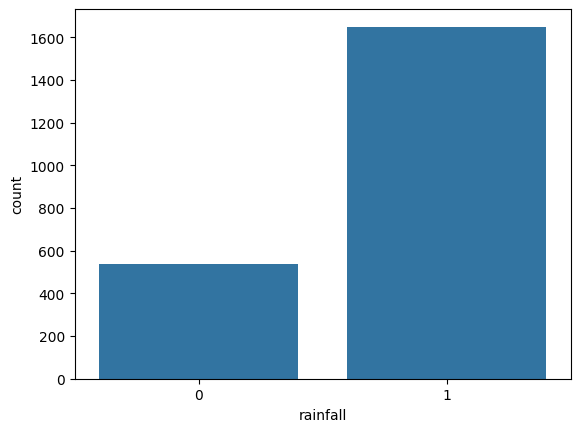

In [6]:
sns.countplot(x='rainfall', data=df);

In [7]:
df.isnull().sum()

id               0
day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
sunshine         0
winddirection    0
windspeed        0
rainfall         0
dtype: int64

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2190 entries, 0 to 2189
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             2190 non-null   int64  
 1   day            2190 non-null   int64  
 2   pressure       2190 non-null   float64
 3   maxtemp        2190 non-null   float64
 4   temparature    2190 non-null   float64
 5   mintemp        2190 non-null   float64
 6   dewpoint       2190 non-null   float64
 7   humidity       2190 non-null   float64
 8   cloud          2190 non-null   float64
 9   sunshine       2190 non-null   float64
 10  winddirection  2190 non-null   float64
 11  windspeed      2190 non-null   float64
 12  rainfall       2190 non-null   int64  
dtypes: float64(10), int64(3)
memory usage: 222.6 KB


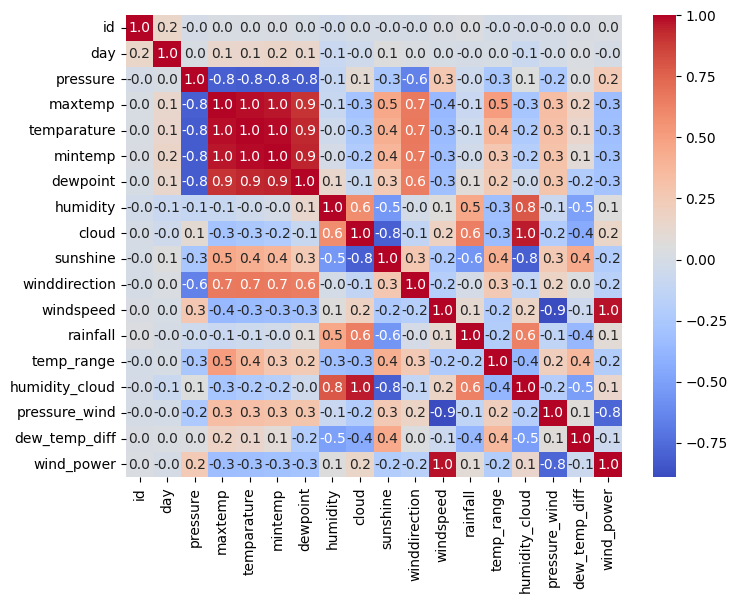

In [39]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".1f", cmap='coolwarm')
plt.show()

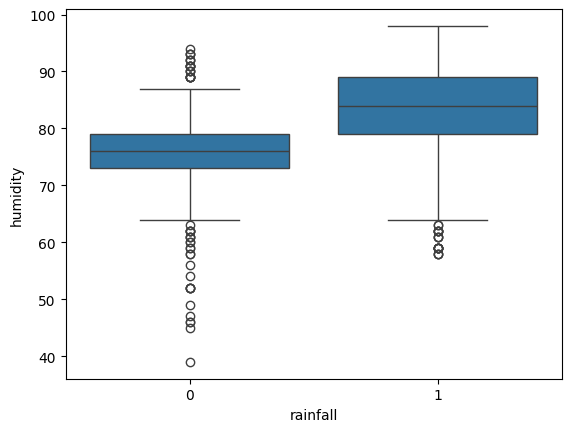

In [13]:
sns.boxplot(x='rainfall', y='humidity', data=df);

In [14]:
cols = ['humidity', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'windspeed']

for col in cols:
    lower_limit = df[col].quantile(0.01) # Alt sınır %1
    upper_limit = df[col].quantile(0.99) # Üst sınır %99
    df[col] = df[col].clip(lower_limit, upper_limit)

In [15]:
df.shape

(2190, 13)

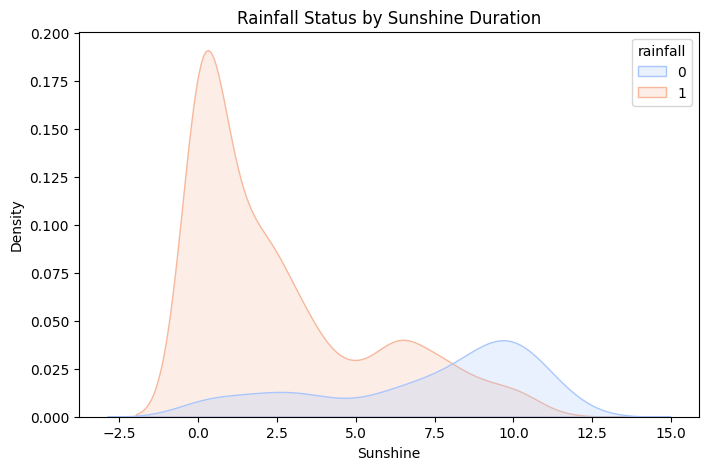

In [32]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x="sunshine", hue="rainfall", fill=True, palette="coolwarm")
plt.title("Rainfall Status by Sunshine Duration")
plt.xlabel("Sunshine");

This density plot (KDE) clearly demonstrates a sharp inverse relationship between sunshine duration and the probability of rainfall. Almost all rainy events (orange area) are clustered near zero sunshine hours, indicating overcast conditions, whereas non-rainy days (blue area) peak significantly when sunshine exceeds 10 hours. A critical threshold is observed around 7.5 hours, beyond which the probability of rain drops dramatically; this confirms that sunshine duration is a highly discriminative and vital feature for our predictive model's performance.

In [37]:
fig = px.histogram(df, x="cloud", color="rainfall",barmode="overlay", opacity=0.7,title="Cloud Distribution vs Rainfall")
fig.show()

The visualization confirms a strong correlation between cloud coverage and rainfall. For non-rainy days (0), cloud coverage is widely distributed with a low average. In contrast, for rainy days (1), cloud coverage is concentrated in a very narrow range, typically exceeding 80%. This provides a crucial insight for the model: if cloud coverage is below 80%, the probability of rainfall is nearly zero.

## Feature Engineering

In [26]:
df['temp_range'] = df['maxtemp'] - df['mintemp']                              # Sıcaklık Farkı 
df['humidity_cloud'] = df['humidity'] * df['cloud']                           # Nem ve Bulut Birleşimi
df['pressure_wind'] = df['pressure'] / (df['windspeed'] + 1)                #  Basınç ve Rüzgar -Fırtına potansiyeli için
df["dew_temp_diff"] = df["temparature"] - df["dewpoint"]             #Eğer bu fark sıfıra yakınsa, sis veya yağmur ihtimali çok yüksektir.
df["wind_power"] = df["windspeed"] ** 2                              #Rüzgar hızının karesini almak, sert hava değişimlerini modelin daha iyi "hissetmesini" sağlar.

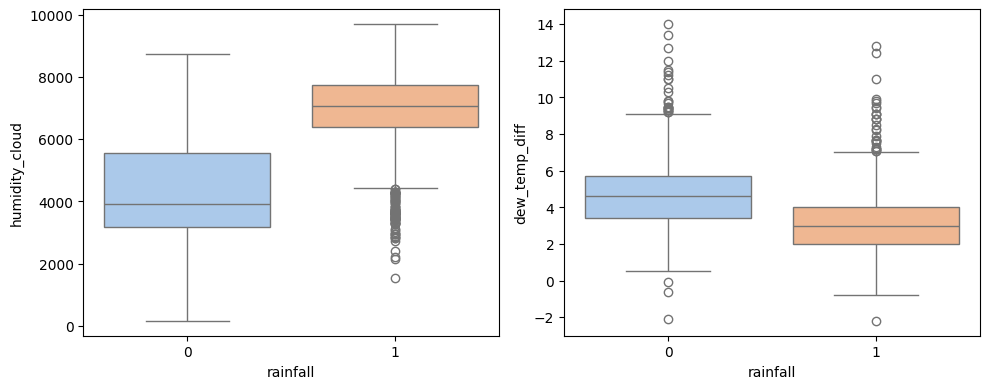

In [41]:
plt.figure(figsize=(10, 4))
for i, feat in enumerate(['humidity_cloud', 'dew_temp_diff']):
    plt.subplot(1, 2, i+1)
    sns.boxplot(data=df, x='rainfall', y=feat, palette='pastel')
plt.tight_layout();

In the humidity_cloud plot, the higher and more concentrated box for rainy days proves that the combination of high humidity and dense cloud cover is a non-negotiable trigger for rain. Conversely, the dew_temp_diff is significantly closer to zero during rainy events, confirming that precipitation occurs as the air reaches saturation. The distinct lack of overlap between the boxes in both plots indicates these are high-impact signals that will directly enhance the model's ROC-AUC performance.

In [42]:
le = LabelEncoder()
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    df_train[col] = le.fit_transform(df_train[col])
    df_test[col] = df_test[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

## Data Processing

In [43]:
x = df.drop(columns=["rainfall", "id"])
y = df["rainfall"]

In [44]:
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.20,random_state=42,stratify=y)

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

## Modelling

In [56]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(x_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [57]:
log_probs = log_reg.predict_proba(x_test)[:, 1]
print(f"Logistic Regression ROC-AUC: {roc_auc_score(y_test, log_probs):.5f}")

Logistic Regression ROC-AUC: 0.87960


In [45]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report)

from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier

# -----------------------------
# MODELLER
# -----------------------------
l  = LogisticRegression(max_iter=1000, n_jobs=-1)
d  = DecisionTreeClassifier(random_state=42)
r  = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
gb = GradientBoostingClassifier(random_state=42)
ab = AdaBoostClassifier(random_state=42)

lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

xgbm = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    random_state=42,
    verbose=False
)


def algo_test(x, y):
    modeller = [
        l, d, r, gb, ab,
        lgbm, xgbm, cat
    ]

    isimler = [
        "LogisticRegression",
        "DecisionTreeClassifier",
        "RandomForestClassifier",
        "GradientBoostingClassifier",
        "AdaBoostClassifier",
        "LightGBM",
        "XGBoost",
        "CatBoost"
    ]

    x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.20,random_state=42,stratify=y)

    accuracy, precision, recall, f1, roc_auc, mdl = [], [], [], [], [], []

    print("Veriler hazır, modeller deneniyor...\n")

    for model in modeller:
        print(f"{model.__class__.__name__} modeli eğitiliyor...")
        model.fit(x_train, y_train)

        y_pred = model.predict(x_test)
        y_proba = model.predict_proba(x_test)[:, 1]

        mdl.append(model)
        accuracy.append(accuracy_score(y_test, y_pred))
        precision.append(precision_score(y_test, y_pred))
        recall.append(recall_score(y_test, y_pred))
        f1.append(f1_score(y_test, y_pred))
        roc_auc.append(roc_auc_score(y_test, y_proba))

        print("Confusion Matrix:")
        print(confusion_matrix(y_test, y_pred))
        print("-" * 50)

    print("Eğitim tamamlandı.\n")

    metrics = pd.DataFrame({
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }, index=isimler)

    metrics.sort_values("ROC_AUC", ascending=False, inplace=True)

    print("🏆 En başarılı model:", metrics.index[0])

    best_model = mdl[metrics.index.get_loc(metrics.index[0])]
    y_pred_best = best_model.predict(x_test)

    print("\nBest Model Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred_best))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_best))

    return metrics

In [46]:
algo_test(x,y)

Veriler hazır, modeller deneniyor...

LogisticRegression modeli eğitiliyor...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Confusion Matrix:
[[ 67  41]
 [ 20 310]]
--------------------------------------------------
DecisionTreeClassifier modeli eğitiliyor...
Confusion Matrix:
[[ 54  54]
 [ 47 283]]
--------------------------------------------------
RandomForestClassifier modeli eğitiliyor...
Confusion Matrix:
[[ 69  39]
 [ 20 310]]
--------------------------------------------------
GradientBoostingClassifier modeli eğitiliyor...
Confusion Matrix:
[[ 66  42]
 [ 21 309]]
--------------------------------------------------
AdaBoostClassifier modeli eğitiliyor...
Confusion Matrix:
[[ 68  40]
 [ 24 306]]
--------------------------------------------------
LGBMClassifier modeli eğitiliyor...
[LightGBM] [Info] Number of positive: 1320, number of negative: 432
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002045 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2515
[LightGBM] [Info] Number of data points in the train set: 1752, 

,Accuracy,Precision,Recall,F1,ROC_AUC
LogisticRegression,0.860731,0.883191,0.939394,0.910426,0.879602
GradientBoostingClassifier,0.856164,0.880342,0.936364,0.907489,0.872840
CatBoost,0.858447,0.880682,0.939394,0.909091,0.868911
RandomForestClassifier,0.865297,0.888252,0.939394,0.913108,0.868757
AdaBoostClassifier,0.853881,0.884393,0.927273,0.905325,0.867340
LightGBM,0.856164,0.882521,0.933333,0.907216,0.863384
XGBoost,0.849315,0.879310,0.927273,0.902655,0.860494
DecisionTreeClassifier,0.769406,0.839763,0.857576,0.848576,0.678788


## General Evaluation & Project Result

This study successfully transforms complex meteorological relationships into a meaningful and high-performance predictive model. The analysis reveals that sunshine duration and cloud coverage are the most decisive factors for precipitation; specifically, conditions where cloud cover exceeds 80% and sunshine approaches zero have been identified as "critical triggers" for rain. Engineered features such as humidity_cloud and dew_temp_diff have sharpened the signals within the data, allowing even a Logistic Regression model to achieve a remarkably high ROC-AUC score of 0.8796. Ultimately, the model has mathematically validated the physical consistency between atmospheric saturation and solar radiation, demonstrating meteorological precision in distinguishing rainfall events.

In [59]:
import joblib
from sklearn.metrics import classification_report, accuracy_score

In [61]:
model_data = {"model": log_reg,"features": list(x.columns)}                       # Şampiyon modelini ve sütun listesini tek bir pakette birleştir
joblib.dump(model_data, "weather_model.joblib")

['weather_model.joblib']

### Hold-out Test Performance

In [65]:
data = joblib.load("weather_model.joblib")
model = data["model"]
features = data["features"]

x_test = x_test[features]
test_preds = model.predict(x_test)

In [67]:
print("--- 🚀 Hold-out Test Performance ---")
print(f"Accuracy: {accuracy_score(y_test, test_preds):.4f}")
print("\n--- Classification Report ---")
# Dikkat: 0 'No Rain', 1 'Rain' olduğu için isimleri buna göre güncelledim
print(classification_report(y_test, test_preds, target_names=["No Rain (0)", "Rain (1)"]))

--- 🚀 Hold-out Test Performance ---
Accuracy: 0.8607

--- Classification Report ---
              precision    recall  f1-score   support

 No Rain (0)       0.77      0.62      0.69       108
    Rain (1)       0.88      0.94      0.91       330

    accuracy                           0.86       438
   macro avg       0.83      0.78      0.80       438
weighted avg       0.86      0.86      0.86       438



The model demonstrates an impressive Accuracy of 86% on the unseen test set, proving its strong generalization capability. The most remarkable finding is the 94% Recall for the Rain (1) class, which indicates that the model is exceptionally sensitive at identifying actual rainfall events and misses only a marginal fraction of storms. While the Recall for No Rain (0) is lower at 62%, this suggests a cautious "safety-first" bias where the model tends to predict rain whenever humidity and cloud signals are high. Overall, a 0.91 F1-score for rain prediction establishes this model as a highly reliable tool for meteorological forecasting.